# Urdu-English Code-Switching Speech Dataset
## Speech Processing Project — EDA & Preprocessing

## 1. Imports & Paths

In [1]:
import os
import re
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import librosa
import librosa.display
import soundfile as sf
import whisper
from sacrebleu.metrics import BLEU, CHRF

In [3]:
AUDIO_DIR  = "Code Switching/Audios/"
METADATA   = "Code Switching/Translations.xlsx"
OUTPUT_DIR = "Audios_Processed"

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110
os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Paths configured.")
print("Audio folder:", os.path.abspath(AUDIO_DIR))


Paths configured.
Audio folder: C:\Users\Microsoft\Code Switching\Audios


## 2. Load & Inspect Metadata

In [4]:
df = pd.read_excel(METADATA)
print("Shape:", df.shape)

Shape: (60, 6)


In [5]:
print("Columns:", df.columns.tolist())

Columns: ['audio_file', 'speaker_id', 'gender', 'roman_urdu_english', 'nastaliq_urdu_english', 'english_translation']


In [6]:
df.head(5)

,audio_file,speaker_id,gender,roman_urdu_english,nastaliq_urdu_english,english_translation
0,001.wav,S01,Female,Aaj ki meeting ka agenda kya hai?,آج کی meeting کا agenda کیا ہے؟,What is today's meeting agenda?
1,002.wav,S01,Female,Yeh project ki deadline extend nahi ho sakti.,یہ project کی deadline extend نہیں ہو سکتی۔,This project's deadline cannot be extended.
2,003.wav,S01,Female,Report submit karne se pehle manager ko review...,Report submit کرنے سے پہلے manager کو review ک...,Get the report reviewed by the manager before ...
3,004.wav,S01,Female,Client ne feedback diya hai ke design approve ...,Client نے feedback دیا ہے کہ design approve نہ...,The client has given feedback that the design ...
4,005.wav,S01,Female,Kal tak yeh presentation ready honi chahiye.,کل تک یہ presentation ready ہونی چاہیے۔,This presentation should be ready by tomorrow.


## 3. Audio Quality Scan
Extracts duration, RMS energy, and speech content % for every file.

In [7]:
audio_stats = []

for fname in sorted(os.listdir(AUDIO_DIR)):
    if not fname.endswith('.wav'):
        continue
    path = os.path.join(AUDIO_DIR, fname)
    try:
        y, sr = librosa.load(path, sr=None, mono=True)
        duration     = librosa.get_duration(y=y, sr=sr)
        rms          = float(np.sqrt(np.mean(y**2)))
        intervals    = librosa.effects.split(y, top_db=30)
        speech_samps = sum(e - s for s, e in intervals)
        speech_pct   = round(speech_samps / len(y) * 100, 1) if len(y) else 0

        issues = []
        if duration < 1.5:   issues.append("TOO SHORT")
        if speech_pct < 40:  issues.append("MOSTLY SILENT")
        if rms < 0.008:      issues.append("LOW VOLUME")
        if sr != 16000:      issues.append(f"SR={sr}")

        audio_stats.append({
            "audio_file"  : fname,
            "sample_rate" : sr,
            "duration_s"  : round(duration, 2),
            "rms_energy"  : round(rms, 4),
            "speech_pct"  : speech_pct,
            "issues"      : ", ".join(issues) if issues else "OK"
        })
    except Exception as e:
        audio_stats.append({"audio_file": fname, "sample_rate": "ERR",
                            "duration_s": 0, "rms_energy": 0,
                            "speech_pct": 0, "issues": str(e)})

stats_df = pd.DataFrame(audio_stats)
full_df  = df.merge(stats_df, on="audio_file", how="left")

print(f"Total files scanned : {len(stats_df)}")
print(f"All at 16,000 Hz    : {(stats_df['sample_rate']==16000).all()}")
print(f"Files with issues   : {(stats_df['issues']!='OK').sum()}")
print(f"Total duration      : {stats_df['duration_s'].sum():.1f}s  ({stats_df['duration_s'].sum()/60:.1f} min)")

Total files scanned : 60
All at 16,000 Hz    : True
Files with issues   : 0
Total duration      : 249.5s  (4.2 min)


In [8]:
stats_df

,audio_file,sample_rate,duration_s,rms_energy,speech_pct,issues
0,001.wav,16000,3.44,0.1081,77.7,OK
1,002.wav,16000,3.42,0.1289,81.3,OK
2,003.wav,16000,4.00,0.1176,88.0,OK
3,004.wav,16000,3.86,0.1150,83.8,OK
4,005.wav,16000,3.18,0.1267,84.9,OK
5,006.wav,16000,4.54,0.1298,83.2,OK
6,007.wav,16000,3.56,0.1097,88.3,OK
7,008.wav,16000,3.56,0.1118,89.2,OK
8,009.wav,16000,4.20,0.1559,87.7,OK
9,010.wav,16000,3.56,0.1152,80.0,OK


### 3.1 Descriptive Statistics

In [9]:
print("Duration (seconds):")
print(stats_df["duration_s"].describe().round(2).to_string())

Duration (seconds):
count    60.00
mean      4.16
std       0.91
min       2.68
25%       3.50
50%       4.03
75%       4.55
max       6.70


In [10]:
print("RMS Energy:")
print(stats_df["rms_energy"].describe().round(4).to_string())

RMS Energy:
count    60.0000
mean      0.1105
std       0.0192
min       0.0675
25%       0.0997
50%       0.1094
75%       0.1212
max       0.1574


In [11]:
print("Speech Content %:")
print(stats_df["speech_pct"].describe().round(1).to_string())

Speech Content %:
count    60.0
mean     78.5
std       8.3
min      54.7
25%      73.0
50%      80.0
75%      83.9
max      96.7


### 3.2 Flagged Files

In [12]:
flagged = stats_df[stats_df["issues"] != "OK"]
if flagged.empty:
    print("No issues found — all 60 files are clean.")
else:
    print(f"{len(flagged)} files flagged:")
    print(flagged[["audio_file","duration_s","rms_energy","speech_pct","issues"]].to_string(index=False))


No issues found — all 60 files are clean.


## 4. EDA Visualizations

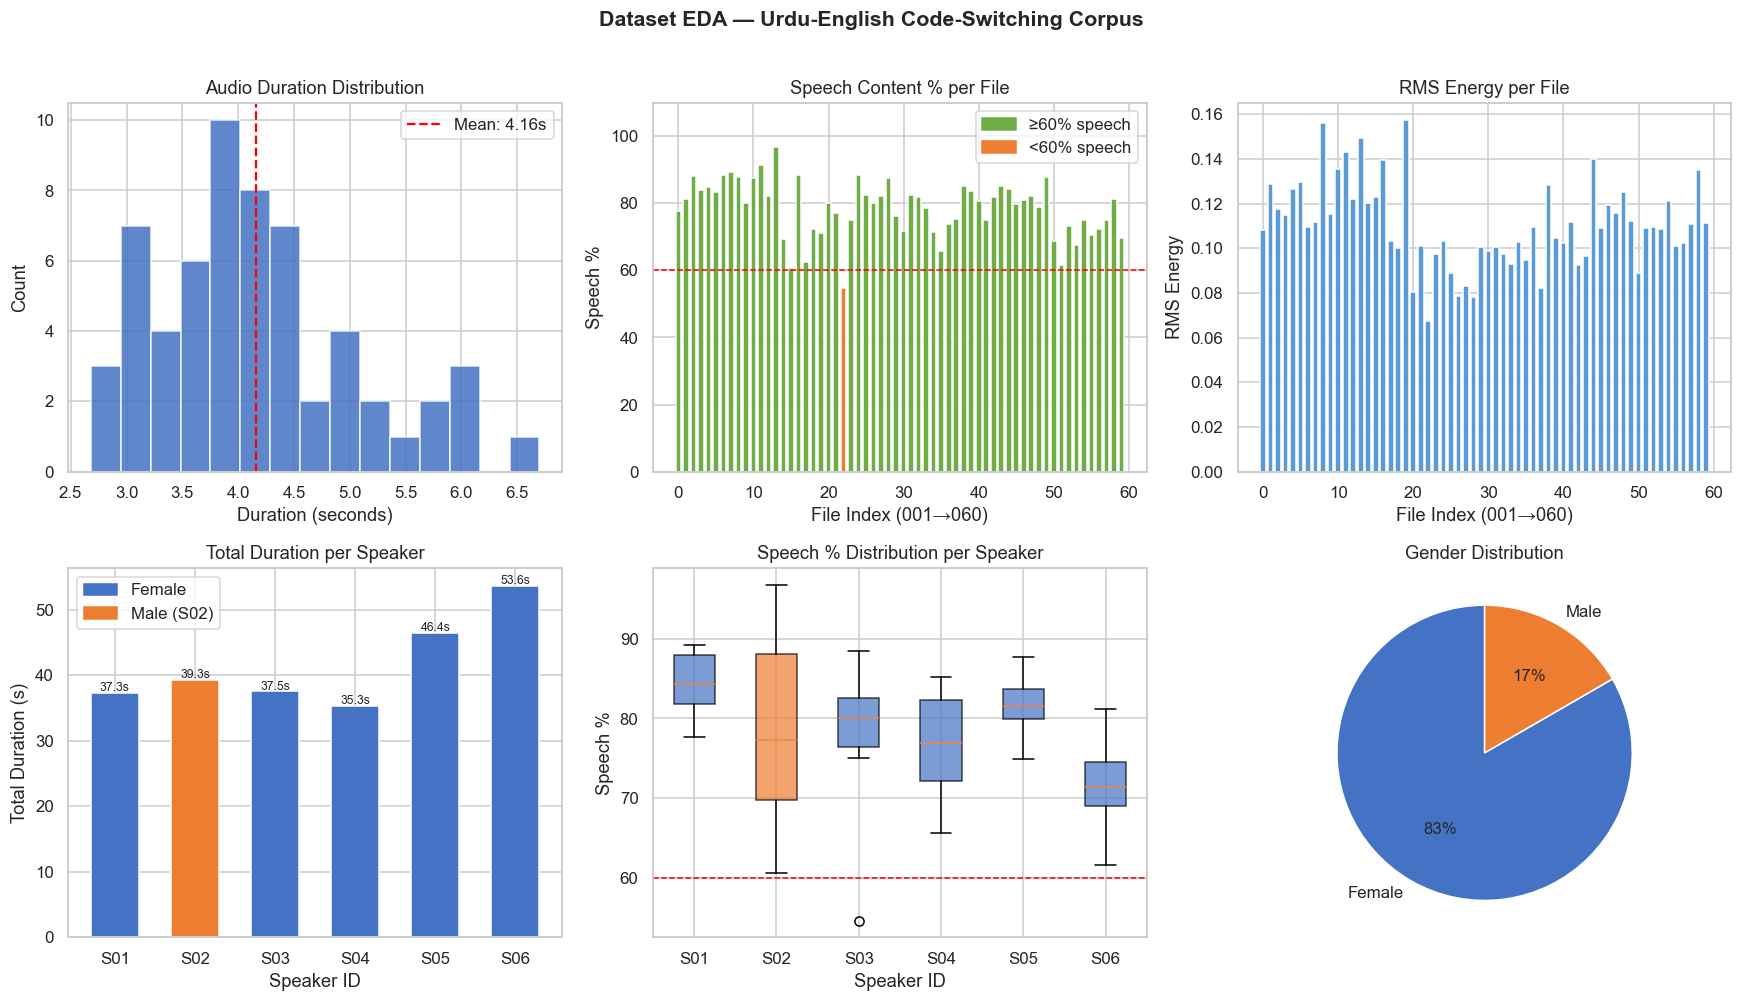

Saved: eda_overview.png


In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Dataset EDA — Urdu-English Code-Switching Corpus", fontsize=14, fontweight='bold', y=1.01)

# 1. Duration histogram
axes[0,0].hist(stats_df["duration_s"], bins=15, color="#4472C4", edgecolor='white', alpha=0.85)
axes[0,0].axvline(stats_df["duration_s"].mean(), color='red', linestyle='--',
                  label=f'Mean: {stats_df["duration_s"].mean():.2f}s')
axes[0,0].set_title("Audio Duration Distribution")
axes[0,0].set_xlabel("Duration (seconds)")
axes[0,0].set_ylabel("Count")
axes[0,0].legend()

# 2. Speech % per file
colors = ["#ED7D31" if p < 60 else "#70AD47" for p in stats_df["speech_pct"]]
axes[0,1].bar(range(len(stats_df)), stats_df["speech_pct"], color=colors, width=0.75)
axes[0,1].axhline(60, color='red', linestyle='--', linewidth=1)
axes[0,1].set_title("Speech Content % per File")
axes[0,1].set_xlabel("File Index (001→060)")
axes[0,1].set_ylabel("Speech %")
axes[0,1].set_ylim(0, 110)
ok_p  = mpatches.Patch(color='#70AD47', label='≥60% speech')
low_p = mpatches.Patch(color='#ED7D31', label='<60% speech')
axes[0,1].legend(handles=[ok_p, low_p])

# 3. RMS Energy per file
axes[0,2].bar(range(len(stats_df)), stats_df["rms_energy"], color="#5B9BD5", width=0.75)
axes[0,2].set_title("RMS Energy per File")
axes[0,2].set_xlabel("File Index (001→060)")
axes[0,2].set_ylabel("RMS Energy")

# 4. Duration by speaker
spk_dur = full_df.groupby("speaker_id")["duration_s"].agg(['sum','mean']).round(2)
spk_colors = ["#ED7D31" if sid=="S02" else "#4472C4" for sid in spk_dur.index]
axes[1,0].bar(spk_dur.index, spk_dur["sum"], color=spk_colors, width=0.6)
axes[1,0].set_title("Total Duration per Speaker")
axes[1,0].set_xlabel("Speaker ID")
axes[1,0].set_ylabel("Total Duration (s)")
for i,(sid,row) in enumerate(spk_dur.iterrows()):
    axes[1,0].text(i, row["sum"]+0.3, f'{row["sum"]:.1f}s', ha='center', fontsize=8)
male_p   = mpatches.Patch(color='#ED7D31', label='Male (S02)')
female_p = mpatches.Patch(color='#4472C4', label='Female')
axes[1,0].legend(handles=[female_p, male_p])

# 5. Speech % by speaker (boxplot)
spk_order = sorted(full_df["speaker_id"].unique())
data_by_spk = [full_df[full_df["speaker_id"]==s]["speech_pct"].values for s in spk_order]
bp = axes[1,1].boxplot(data_by_spk, labels=spk_order, patch_artist=True)
spk_colors2 = ["#ED7D31" if s=="S02" else "#4472C4" for s in spk_order]
for patch, color in zip(bp['boxes'], spk_colors2):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1,1].set_title("Speech % Distribution per Speaker")
axes[1,1].set_xlabel("Speaker ID")
axes[1,1].set_ylabel("Speech %")
axes[1,1].axhline(60, color='red', linestyle='--', linewidth=1)

# 6. Gender pie
gender_counts = full_df["gender"].value_counts()
axes[1,2].pie(gender_counts.values, labels=gender_counts.index,
              colors=["#4472C4","#ED7D31"], autopct='%1.0f%%',
              startangle=90, textprops={'fontsize':11})
axes[1,2].set_title("Gender Distribution")

plt.tight_layout()
plt.savefig("eda_overview.png", bbox_inches='tight', dpi=120)
plt.show()
print("Saved: eda_overview.png")


## 5. Waveform Visualization
Inspect any file visually. Change `fname` to check different files.

In [14]:
def plot_waveform(fname="023.wav"):
    """Plot waveform for a single file. Change fname to inspect any file."""
    path = os.path.join(AUDIO_DIR, fname)
    y, sr = librosa.load(path, sr=None)
    row = full_df[full_df["audio_file"]==fname].iloc[0]

    fig, axes = plt.subplots(2, 1, figsize=(12, 5))
    fig.suptitle(f"{fname} | Speaker: {row['speaker_id']} | Gender: {row['gender']}", fontweight='bold')

    # Waveform
    librosa.display.waveshow(y, sr=sr, ax=axes[0], color="#4472C4", alpha=0.8)
    axes[0].set_title(f"Waveform — Speech: {row['speech_pct']}% | Duration: {row['duration_s']}s | RMS: {row['rms_energy']}")
    axes[0].set_ylabel("Amplitude")

    # Mel spectrogram
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=80)
    S_db = librosa.power_to_db(S, ref=np.max)
    img = librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='mel', ax=axes[1])
    fig.colorbar(img, ax=axes[1], format='%+2.0f dB')
    axes[1].set_title("Mel Spectrogram")

    plt.tight_layout()
    plt.show()
    print("Transcription :", row['roman_urdu_english'])
    print("Translation   :", row['english_translation'])

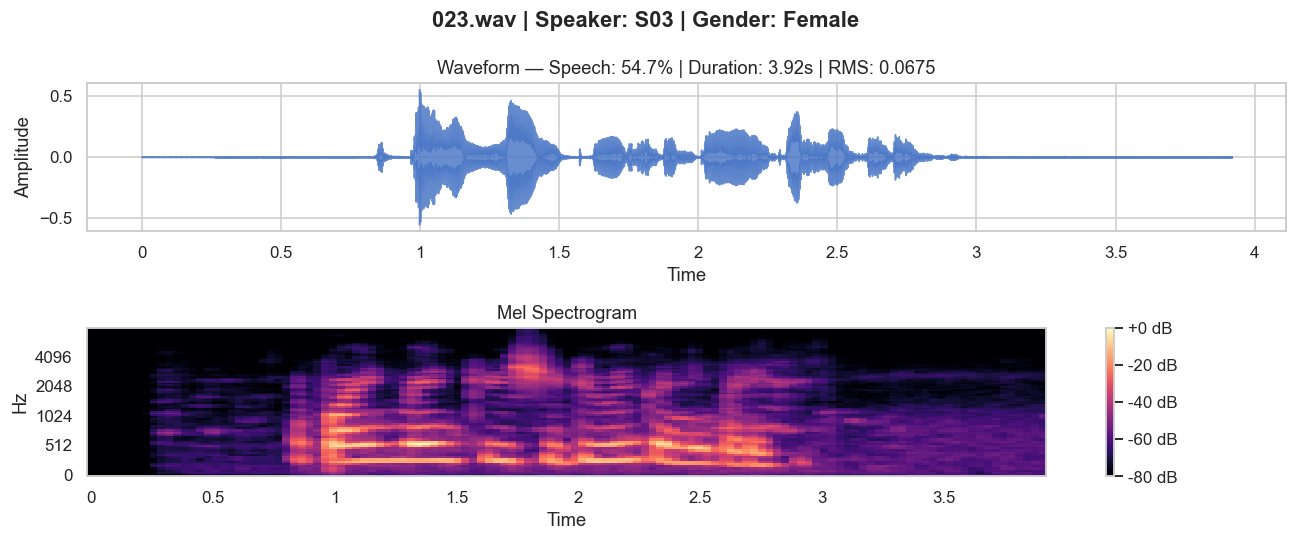

Transcription : Appointment reschedule karni paregi.
Translation   : The appointment will have to be rescheduled.


In [15]:
plot_waveform("023.wav")

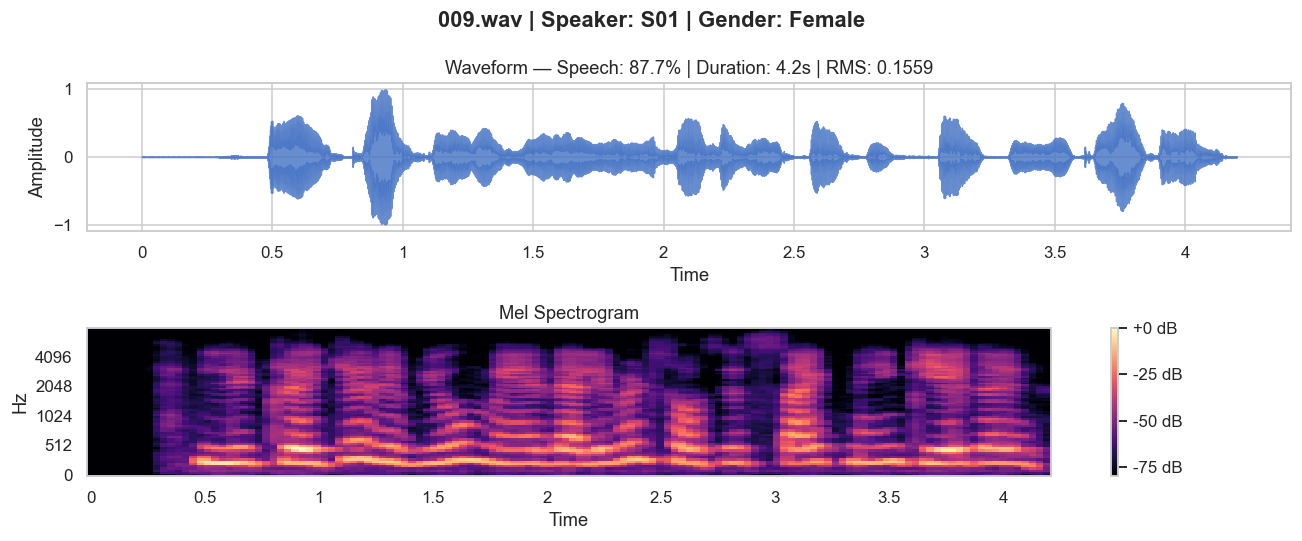

Transcription : Literature review mein relevant sources cite nahi kiye gaye.
Translation   : Relevant sources were not cited in the literature review.


In [16]:
plot_waveform("009.wav")

## 6. Preprocessing Pipeline
Three steps applied to every file:
1. **Resample** to 16,000 Hz (already correct, but enforced for safety)
2. **Trim silence** from start and end (top_db=25)
3. **Normalize** peak amplitude to 0.9

Output saved to `Audios_Processed/` — original files untouched.


In [17]:
TARGET_SR = 16000
log = []

for fname in sorted(os.listdir(AUDIO_DIR)):
    if not fname.endswith('.wav'):
        continue
    in_path  = os.path.join(AUDIO_DIR, fname)
    out_path = os.path.join(OUTPUT_DIR, fname)
    try:
        y, sr = librosa.load(in_path, sr=TARGET_SR, mono=True)
        orig_dur = librosa.get_duration(y=y, sr=sr)

        # Trim silence
        y_trimmed, _ = librosa.effects.trim(y, top_db=25)

        # Normalize
        peak = np.max(np.abs(y_trimmed))
        y_norm = y_trimmed * (0.9 / peak) if peak > 0 else y_trimmed

        new_dur = librosa.get_duration(y=y_norm, sr=TARGET_SR)
        sf.write(out_path, y_norm, TARGET_SR, subtype='PCM_16')

        log.append({"file": fname,
                    "orig_dur_s": round(orig_dur, 2),
                    "proc_dur_s": round(new_dur, 2),
                    "trimmed_s" : round(orig_dur - new_dur, 2),
                    "status": "OK"})
    except Exception as e:
        log.append({"file": fname, "orig_dur_s": 0, "proc_dur_s": 0,
                    "trimmed_s": 0, "status": f"ERROR: {e}"})

log_df = pd.DataFrame(log)
errors = log_df[log_df["status"] != "OK"]
print(f"Processed {len(log_df)} files → '{OUTPUT_DIR}/'")
print(f"   Avg silence trimmed : {log_df['trimmed_s'].mean():.3f}s per file")
print(f"   Errors              : {len(errors)}")
if not errors.empty:
    print(errors)

Processed 60 files → 'Audios_Processed/'
   Avg silence trimmed : 0.829s per file
   Errors              : 0


In [18]:
log_df

,file,orig_dur_s,proc_dur_s,trimmed_s,status
0,001.wav,3.44,2.80,0.64,OK
1,002.wav,3.42,2.94,0.48,OK
2,003.wav,4.00,3.58,0.42,OK
3,004.wav,3.86,3.23,0.63,OK
4,005.wav,3.18,2.70,0.48,OK
5,006.wav,4.54,3.90,0.63,OK
6,007.wav,3.56,3.17,0.38,OK
7,008.wav,3.56,3.21,0.35,OK
8,009.wav,4.20,3.74,0.45,OK
9,010.wav,3.56,2.85,0.71,OK


### 6.1 Before vs After — Visual Check

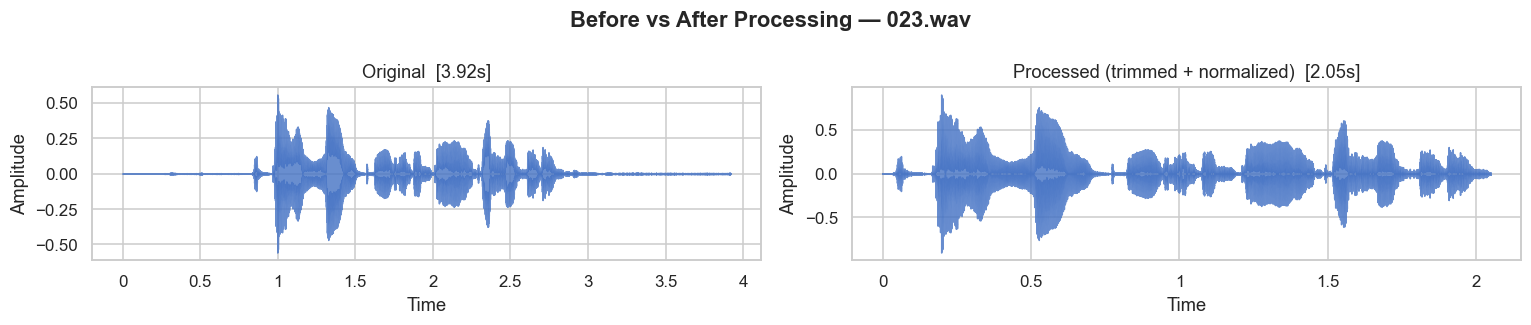

In [19]:
def compare_before_after(fname="015.wav"):
    """Compare original vs processed waveform side by side."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 3))
    fig.suptitle(f"Before vs After Processing — {fname}", fontweight='bold')
    for ax, folder, label in zip(
        axes,
        [AUDIO_DIR, OUTPUT_DIR],
        ["Original", "Processed (trimmed + normalized)"]
    ):
        y, sr = librosa.load(os.path.join(folder, fname), sr=None)
        librosa.display.waveshow(y, sr=sr, ax=ax, color="#4472C4", alpha=0.8)
        dur = librosa.get_duration(y=y, sr=sr)
        ax.set_title(f"{label}  [{dur:.2f}s]")
        ax.set_ylabel("Amplitude")
    plt.tight_layout()
    plt.show()

compare_before_after("023.wav") 


## 7. Export Clean Metadata
This CSV is the input for the next notebook (Whisper transcription + translation).

In [20]:
full_df["processed_path"] = full_df["audio_file"].apply(
    lambda x: os.path.join(OUTPUT_DIR, x)
)

# Add sentence length as extra feature
full_df["word_count"] = full_df["roman_urdu_english"].apply(lambda x: len(str(x).split()))

# Save
full_df.to_csv("dataset_clean.csv", index=False, encoding="utf-8-sig")
print("Saved: dataset_clean.csv")
print(f"   Rows: {len(full_df)} | Columns: {full_df.columns.tolist()}")
full_df[["audio_file","speaker_id","gender","duration_s","speech_pct","word_count","issues"]].head(10)


Saved: dataset_clean.csv
   Rows: 60 | Columns: ['audio_file', 'speaker_id', 'gender', 'roman_urdu_english', 'nastaliq_urdu_english', 'english_translation', 'sample_rate', 'duration_s', 'rms_energy', 'speech_pct', 'issues', 'processed_path', 'word_count']


,audio_file,speaker_id,gender,duration_s,speech_pct,word_count,issues
0,001.wav,S01,Female,3.44,77.7,7,OK
1,002.wav,S01,Female,3.42,81.3,8,OK
2,003.wav,S01,Female,4.00,88.0,10,OK
3,004.wav,S01,Female,3.86,83.8,10,OK
4,005.wav,S01,Female,3.18,84.9,7,OK
5,006.wav,S01,Female,4.54,83.2,12,OK
6,007.wav,S01,Female,3.56,88.3,9,OK
7,008.wav,S01,Female,3.56,89.2,8,OK
8,009.wav,S01,Female,4.20,87.7,9,OK
9,010.wav,S01,Female,3.56,80.0,7,OK


## 8. Dataset Summary Report

In [21]:
print("=" * 55)
print("   URDU-ENGLISH CODE-SWITCHING DATASET SUMMARY")
print("=" * 55)
print(f"  Total files          : {len(stats_df)}")
print(f"  Total duration       : {stats_df['duration_s'].sum():.1f}s  ({stats_df['duration_s'].sum()/60:.1f} min)")
print(f"  Avg duration / file  : {stats_df['duration_s'].mean():.2f}s")
print(f"  Min / Max duration   : {stats_df['duration_s'].min():.2f}s / {stats_df['duration_s'].max():.2f}s")
print(f"  Sample rate          : 16,000 Hz (all files)")
print(f"  Avg speech content   : {stats_df['speech_pct'].mean():.1f}%")
print(f"  Files with issues    : {(stats_df['issues']!='OK').sum()}")
print()
print("  SPEAKERS:")
for _, row in full_df.groupby(["speaker_id","gender"])["duration_s"].agg(['count','sum']).reset_index().iterrows():
    print(f"    {row['speaker_id']} ({row['gender']:<6}) : {int(row['count'])} files, {row['sum']:.1f}s total")

   URDU-ENGLISH CODE-SWITCHING DATASET SUMMARY
  Total files          : 60
  Total duration       : 249.5s  (4.2 min)
  Avg duration / file  : 4.16s
  Min / Max duration   : 2.68s / 6.70s
  Sample rate          : 16,000 Hz (all files)
  Avg speech content   : 78.5%
  Files with issues    : 0

  SPEAKERS:
    S01 (Female) : 10 files, 37.3s total
    S02 (Male  ) : 10 files, 39.3s total
    S03 (Female) : 10 files, 37.5s total
    S04 (Female) : 10 files, 35.3s total
    S05 (Female) : 10 files, 46.4s total
    S06 (Female) : 10 files, 53.6s total


# Part B: Transcription & Translation Pipeline
## 1. Load Clean Dataset

In [22]:
CLEAN_CSV  = "dataset_clean.csv"
AUDIO_DIR  = "Audios_Processed/"
RESULTS    = "results.csv"

In [23]:
df = pd.read_csv(CLEAN_CSV, encoding='utf-8-sig')
print("Shape:", df.shape)

Shape: (60, 13)


In [24]:
print("Columns:", df.columns.tolist())

Columns: ['audio_file', 'speaker_id', 'gender', 'roman_urdu_english', 'nastaliq_urdu_english', 'english_translation', 'sample_rate', 'duration_s', 'rms_energy', 'speech_pct', 'issues', 'processed_path', 'word_count']


In [25]:
df[["audio_file","speaker_id","gender","roman_urdu_english","english_translation"]].head(5)

,audio_file,speaker_id,gender,roman_urdu_english,english_translation
0,001.wav,S01,Female,Aaj ki meeting ka agenda kya hai?,What is today's meeting agenda?
1,002.wav,S01,Female,Yeh project ki deadline extend nahi ho sakti.,This project's deadline cannot be extended.
2,003.wav,S01,Female,Report submit karne se pehle manager ko review...,Get the report reviewed by the manager before ...
3,004.wav,S01,Female,Client ne feedback diya hai ke design approve ...,The client has given feedback that the design ...
4,005.wav,S01,Female,Kal tak yeh presentation ready honi chahiye.,This presentation should be ready by tomorrow.


## 2. Load Whisper Model

In [26]:
print("Loading Whisper medium model...")
t0 = time.time()
whisper_model = whisper.load_model("medium")
print(f"Whisper loaded in {time.time()-t0:.1f}s")

Loading Whisper medium model...
Whisper loaded in 34.8s


## 3. File Test

In [27]:
TEST_FILE = "003.wav"   
test_path = os.path.join(AUDIO_DIR, TEST_FILE)

gt_row = df[df["audio_file"] == TEST_FILE].iloc[0]

print("=" * 20)
print("FILE:", TEST_FILE)
print("=" * 20)
print("Ground Truth (Roman)  :", gt_row["roman_urdu_english"])
print("Ground Truth (English):", gt_row["english_translation"])
print()

# Whisper direct translation — no language forcing
print("Running Whisper (task=translate)")
t0 = time.time()
result = whisper_model.transcribe(test_path, task="translate")
whisper_english = result["text"].strip()
elapsed = time.time() - t0

print(f"Whisper English Output: {whisper_english}")
print(f"Time taken            : {elapsed:.2f}s")
print()

# Quick BLEU check
bleu_metric = BLEU(effective_order=True)
score = bleu_metric.sentence_score(whisper_english, [gt_row["english_translation"]])
print(f"BLEU Score (this file): {score.score:.2f}")

FILE: 003.wav
Ground Truth (Roman)  : Report submit karne se pehle manager ko review karwa lo.
Ground Truth (English): Get the report reviewed by the manager before submitting.

Running Whisper (task=translate)
Whisper English Output: Before submitting the report, get the manager to review it.
Time taken            : 40.47s

BLEU Score (this file): 10.60


In [28]:
TEST_FILE = "032.wav"   
test_path = os.path.join(AUDIO_DIR, TEST_FILE)

gt_row = df[df["audio_file"] == TEST_FILE].iloc[0]

print("=" * 20)
print("FILE:", TEST_FILE)
print("=" * 20)
print("Ground Truth (Roman)  :", gt_row["roman_urdu_english"])
print("Ground Truth (English):", gt_row["english_translation"])
print()

# Whisper direct translation — no language forcing
print("Running Whisper (task=translate)")
t0 = time.time()
result = whisper_model.transcribe(test_path, task="translate")
whisper_english = result["text"].strip()
elapsed = time.time() - t0

print(f"Whisper English Output: {whisper_english}")
print(f"Time taken            : {elapsed:.2f}s")
print()

# Quick BLEU check
bleu_metric = BLEU(effective_order=True)
score = bleu_metric.sentence_score(whisper_english, [gt_row["english_translation"]])
print(f"BLEU Score (this file): {score.score:.2f}")

FILE: 032.wav
Ground Truth (Roman)  : Assignment ka word limit exceed ho gaya hai, trim karna parega.
Ground Truth (English): The assignment's word limit has been exceeded, it will need to be trimmed.

Running Whisper (task=translate)
Whisper English Output: Assignment word limit has exceeded, we will have to trim it
Time taken            : 38.68s

BLEU Score (this file): 13.88


In [29]:
TEST_FILE = "015.wav"   
test_path = os.path.join(AUDIO_DIR, TEST_FILE)

gt_row = df[df["audio_file"] == TEST_FILE].iloc[0]

print("=" * 20)
print("FILE:", TEST_FILE)
print("=" * 20)
print("Ground Truth (Roman)  :", gt_row["roman_urdu_english"])
print("Ground Truth (English):", gt_row["english_translation"])
print()

# Whisper direct translation — no language forcing
print("Running Whisper (task=translate)")
t0 = time.time()
result = whisper_model.transcribe(test_path, task="translate")
whisper_english = result["text"].strip()
elapsed = time.time() - t0

print(f"Whisper English Output: {whisper_english}")
print(f"Time taken            : {elapsed:.2f}s")
print()

# Quick BLEU check
bleu_metric = BLEU(effective_order=True)
score = bleu_metric.sentence_score(whisper_english, [gt_row["english_translation"]])
print(f"BLEU Score (this file): {score.score:.2f}")

FILE: 015.wav
Ground Truth (Roman)  : System ka server down hai, IT department ko inform karo.
Ground Truth (English): The system server is down, inform the IT department.

Running Whisper (task=translate)
Whisper English Output: system server is down inform IT department
Time taken            : 35.72s

BLEU Score (this file): 28.70


## 4. Full Pipeline — All 60 Files

In [30]:
bleu_metric = BLEU(effective_order=True)
chrf_metric = CHRF()
records = []
total = len(df)

print(f"Processing {total} files...")
print("-" * 70)

for idx, row in df.iterrows():
    fname = row["audio_file"]
    path  = os.path.join(AUDIO_DIR, fname)

    if not os.path.exists(path):
        print(f"  [{idx+1:02d}/{total}] {fname} — NOT FOUND, skipping")
        continue

    try:
        t_start = time.time()

        # Whisper: audio → English directly (no language forcing)
        result         = whisper_model.transcribe(path, task="translate")
        whisper_english = result["text"].strip()
        detected_lang  = result.get("language", "unknown")
        elapsed        = time.time() - t_start

        # BLEU score
        ref = str(row["english_translation"]).strip()
        bleu_score = bleu_metric.sentence_score(whisper_english, [ref]).score if whisper_english else 0.0
        chrf_score = chrf_metric.sentence_score(whisper_english, [ref]).score if whisper_english else 0.0

        records.append({
            "audio_file"          : fname,
            "speaker_id"          : row["speaker_id"],
            "gender"              : row["gender"],
            "ground_truth_roman"  : row["roman_urdu_english"],
            "ground_truth_nastaliq": row.get("nastaliq_urdu_english", ""),
            "ground_truth_english": ref,
            "whisper_english"     : whisper_english,
            "detected_language"   : detected_lang,
            "bleu_score"          : round(bleu_score, 2),
            "chrf_score"          : round(chrf_score, 2),
            "processing_time_s"   : round(elapsed, 2),
            "status"              : "OK"
        })

        print(f"  [{idx+1:02d}/{total}] {fname} ({detected_lang}) ✅ {elapsed:.1f}s")
        print(f"    GT  : {ref[:60]}")
        print(f"    OUT : {whisper_english[:60]}")
        print(f"    BLEU: {bleu_score:.1f}  chrF: {chrf_score:.1f}")
        print()

    except Exception as e:
        records.append({
            "audio_file": fname, "speaker_id": row["speaker_id"],
            "gender": row["gender"],
            "ground_truth_roman": row["roman_urdu_english"],
            "ground_truth_nastaliq": row.get("nastaliq_urdu_english",""),
            "ground_truth_english": row["english_translation"],
            "whisper_english": "", "detected_language": "error",
            "bleu_score": 0.0, "chrf_score": 0.0,
            "processing_time_s": 0, "status": f"ERROR: {e}"
        })
        print(f"  [{idx+1:02d}/{total}] {fname} ❌ ERROR: {e}")

results_df = pd.DataFrame(records)
ok_df = results_df[results_df["status"] == "OK"].copy()

print("=" * 30)
print(f"Done. Success: {len(ok_df)} / {total}")
print(f"Mean BLEU : {ok_df['bleu_score'].mean():.2f}")
print(f"Mean chrF : {ok_df['chrf_score'].mean():.2f}")

Processing 60 files...
----------------------------------------------------------------------
  [01/60] 001.wav (ur) ✅ 37.3s
    GT  : What is today's meeting agenda?
    OUT : What is the agenda of today's meeting?
    BLEU: 17.3  chrF: 75.5

  [02/60] 002.wav (hi) ✅ 37.3s
    GT  : This project's deadline cannot be extended.
    OUT : This project's deadline cannot be extended.
    BLEU: 100.0  chrF: 100.0

  [03/60] 003.wav (hi) ✅ 37.6s
    GT  : Get the report reviewed by the manager before submitting.
    OUT : Before submitting the report, get the manager to review it.
    BLEU: 10.6  chrF: 67.3

  [04/60] 004.wav (hi) ✅ 36.4s
    GT  : The client has given feedback that the design was not approv
    OUT : The client has given feedback that the design was not approv
    BLEU: 100.0  chrF: 100.0

  [05/60] 005.wav (hi) ✅ 37.1s
    GT  : This presentation should be ready by tomorrow.
    OUT : Till tomorrow, this presentation should be ready.
    BLEU: 33.0  chrF: 81.9

  [06/60] 0

## 5. Results Table 

In [31]:
pd.set_option('display.max_colwidth', 50)
display_cols = [
    "audio_file","speaker_id","gender",
    "ground_truth_english","whisper_english",
    "bleu_score","chrf_score","detected_language"
]
ok_df[display_cols].head(15)

,audio_file,speaker_id,gender,ground_truth_english,whisper_english,bleu_score,chrf_score,detected_language
0,001.wav,S01,Female,What is today's meeting agenda?,What is the agenda of today's meeting?,17.29,75.46,ur
1,002.wav,S01,Female,This project's deadline cannot be extended.,This project's deadline cannot be extended.,100.00,100.00,hi
2,003.wav,S01,Female,Get the report reviewed by the manager before ...,"Before submitting the report, get the manager ...",10.60,67.29,hi
3,004.wav,S01,Female,The client has given feedback that the design ...,The client has given feedback that the design ...,100.00,100.00,hi
4,005.wav,S01,Female,This presentation should be ready by tomorrow.,"Till tomorrow, this presentation should be ready.",33.03,81.95,hi
5,006.wav,S01,Female,Assign this task to the team and keep tracking...,Assign this task to the team and track the pro...,64.07,76.70,hi
6,007.wav,S01,Female,"There is a budget issue, confirm with the fina...",The issue of budget is to confirm with the fin...,46.17,78.10,hi
7,008.wav,S01,Female,The methodology section of this research paper...,This is the methodology section of the researc...,21.36,76.36,ur
8,009.wav,S01,Female,Relevant sources were not cited in the literat...,Relevant sources were not cited in literature ...,66.90,89.17,hi
9,010.wav,S01,Female,How much time is needed for data collection?,How much time do you need for data collection?,37.99,78.78,hi


## 6. Evaluation Summary

In [32]:
print("=" * 55)
print("   TRANSLATION EVALUATION REPORT")
print("=" * 55)
print("  BLEU SCORE (0=worst, 100=perfect):")
print(f"    Mean   : {ok_df['bleu_score'].mean():.2f}")
print(f"    Median : {ok_df['bleu_score'].median():.2f}")
print(f"    Best   : {ok_df['bleu_score'].max():.2f}  — {ok_df.loc[ok_df['bleu_score'].idxmax(),'audio_file']}")
print(f"    Worst  : {ok_df['bleu_score'].min():.2f}  — {ok_df.loc[ok_df['bleu_score'].idxmin(),'audio_file']}")
print()
print("  chrF SCORE (character-level, more lenient):")
print(f"    Mean   : {ok_df['chrf_score'].mean():.2f}")
print(f"    Median : {ok_df['chrf_score'].median():.2f}")
print()
print("  LANGUAGE DETECTION:")
lang_counts = ok_df["detected_language"].value_counts()
for lang, count in lang_counts.items():
    print(f"    {lang:<12}: {count} files")
print()
total_time = results_df["processing_time_s"].sum()
print(f"  Total processing time : {total_time:.1f}s ({total_time/60:.1f} min)")
print(f"  Avg per file          : {ok_df['processing_time_s'].mean():.2f}s")

   TRANSLATION EVALUATION REPORT
  BLEU SCORE (0=worst, 100=perfect):
    Mean   : 46.17
    Median : 33.61
    Best   : 100.00  — 002.wav
    Worst  : 5.88  — 023.wav

  chrF SCORE (character-level, more lenient):
    Mean   : 76.26
    Median : 75.63

  LANGUAGE DETECTION:
    hi          : 48 files
    ur          : 12 files

  Total processing time : 2315.0s (38.6 min)
  Avg per file          : 38.58s


## 7. Evaluation Visualizations

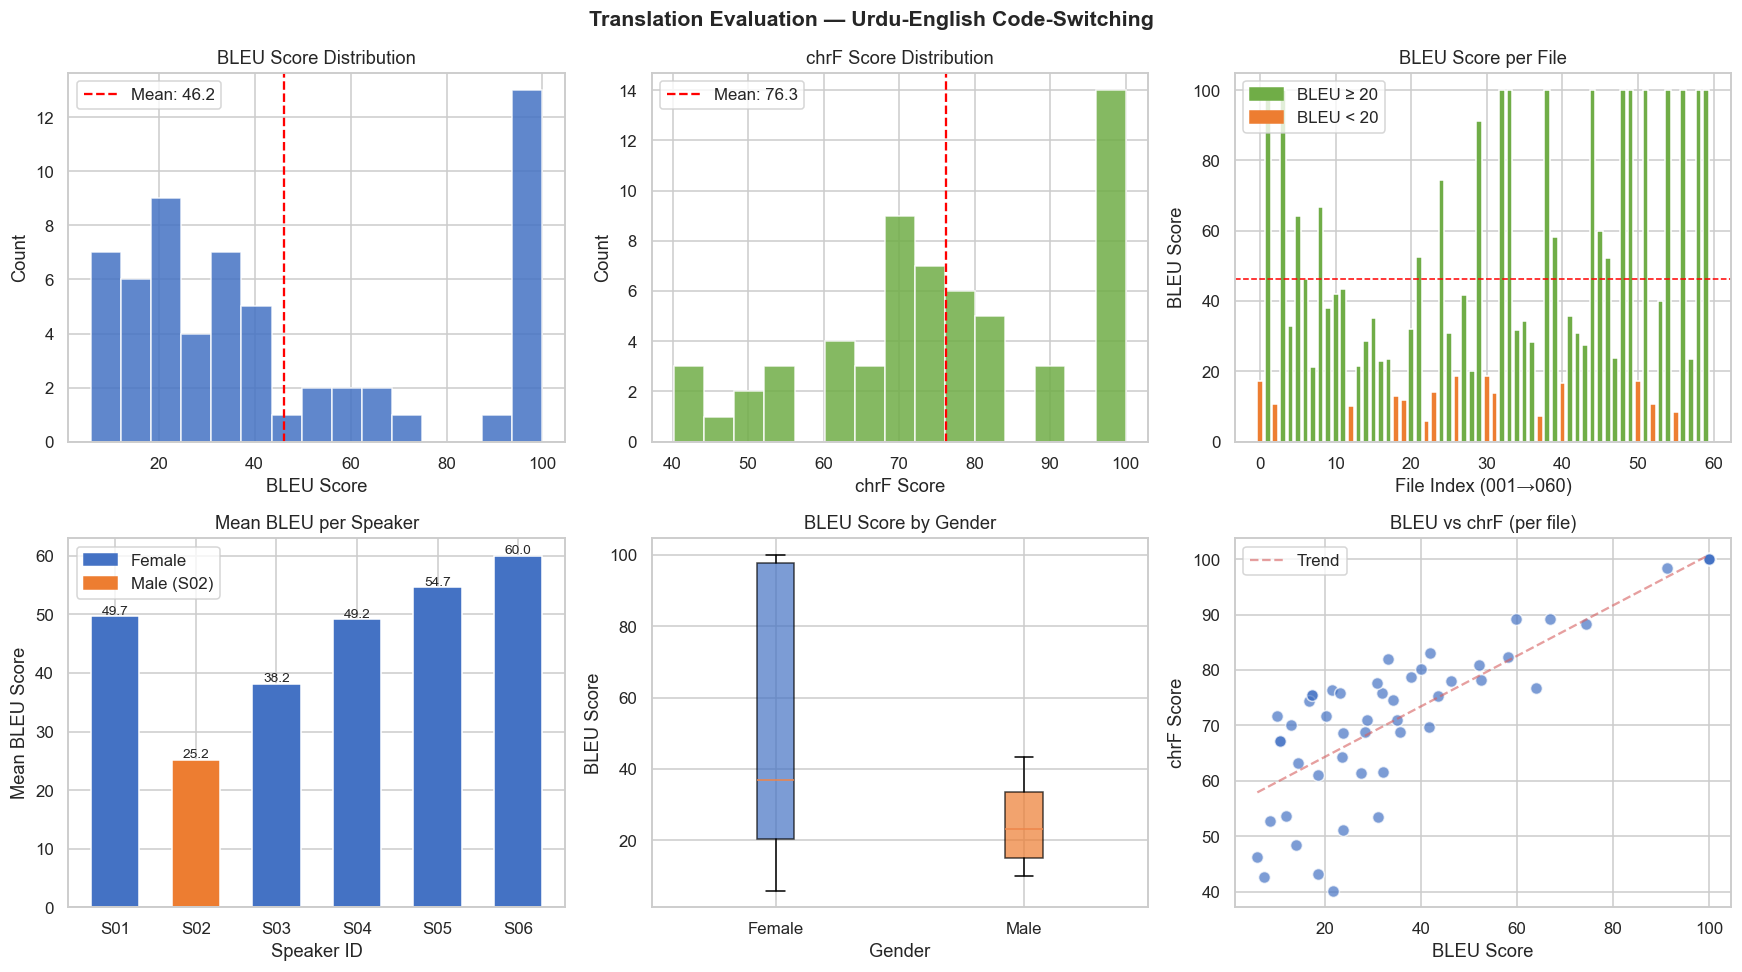

Saved: evaluation_results.png


In [33]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Translation Evaluation — Urdu-English Code-Switching",
             fontsize=14, fontweight='bold')

# 1. BLEU distribution
axes[0,0].hist(ok_df["bleu_score"], bins=15, color="#4472C4", edgecolor='white', alpha=0.85)
axes[0,0].axvline(ok_df["bleu_score"].mean(), color='red', linestyle='--',
                  label=f'Mean: {ok_df["bleu_score"].mean():.1f}')
axes[0,0].set_title("BLEU Score Distribution")
axes[0,0].set_xlabel("BLEU Score")
axes[0,0].set_ylabel("Count")
axes[0,0].legend()

# 2. chrF distribution
axes[0,1].hist(ok_df["chrf_score"], bins=15, color="#70AD47", edgecolor='white', alpha=0.85)
axes[0,1].axvline(ok_df["chrf_score"].mean(), color='red', linestyle='--',
                  label=f'Mean: {ok_df["chrf_score"].mean():.1f}')
axes[0,1].set_title("chrF Score Distribution")
axes[0,1].set_xlabel("chrF Score")
axes[0,1].set_ylabel("Count")
axes[0,1].legend()

# 3. BLEU per file
colors_bleu = ["#70AD47" if b >= 20 else "#ED7D31" for b in ok_df["bleu_score"]]
axes[0,2].bar(range(len(ok_df)), ok_df["bleu_score"], color=colors_bleu, width=0.75)
axes[0,2].axhline(ok_df["bleu_score"].mean(), color='red', linestyle='--', linewidth=1,
                  label=f'Mean: {ok_df["bleu_score"].mean():.1f}')
axes[0,2].set_title("BLEU Score per File")
axes[0,2].set_xlabel("File Index (001→060)")
axes[0,2].set_ylabel("BLEU Score")
axes[0,2].legend()
good_p = mpatches.Patch(color='#70AD47', label='BLEU ≥ 20')
low_p  = mpatches.Patch(color='#ED7D31', label='BLEU < 20')
axes[0,2].legend(handles=[good_p, low_p])

# 4. BLEU per speaker
spk_bleu = ok_df.groupby("speaker_id")["bleu_score"].mean().sort_index()
bar_colors = ["#ED7D31" if s=="S02" else "#4472C4" for s in spk_bleu.index]
axes[1,0].bar(spk_bleu.index, spk_bleu.values, color=bar_colors, width=0.6)
axes[1,0].set_title("Mean BLEU per Speaker")
axes[1,0].set_xlabel("Speaker ID")
axes[1,0].set_ylabel("Mean BLEU Score")
for i,(spk,val) in enumerate(spk_bleu.items()):
    axes[1,0].text(i, val+0.3, f'{val:.1f}', ha='center', fontsize=9)
male_p   = mpatches.Patch(color='#ED7D31', label='Male (S02)')
female_p = mpatches.Patch(color='#4472C4', label='Female')
axes[1,0].legend(handles=[female_p, male_p])

# 5. BLEU per gender boxplot
genders = sorted(ok_df["gender"].unique())
data_by_gen = [ok_df[ok_df["gender"]==g]["bleu_score"].values for g in genders]
bp = axes[1,1].boxplot(data_by_gen, labels=genders, patch_artist=True)
gen_colors = ["#4472C4","#ED7D31"]
for patch, color in zip(bp['boxes'], gen_colors):
    patch.set_facecolor(color); patch.set_alpha(0.7)
axes[1,1].set_title("BLEU Score by Gender")
axes[1,1].set_xlabel("Gender")
axes[1,1].set_ylabel("BLEU Score")

# 6. BLEU vs chrF scatter
axes[1,2].scatter(ok_df["bleu_score"], ok_df["chrf_score"],
                  color="#4472C4", alpha=0.7, edgecolors='white', s=60)
axes[1,2].set_title("BLEU vs chrF (per file)")
axes[1,2].set_xlabel("BLEU Score")
axes[1,2].set_ylabel("chrF Score")
z = np.polyfit(ok_df["bleu_score"], ok_df["chrf_score"], 1)
p = np.poly1d(z)
x_line = np.linspace(ok_df["bleu_score"].min(), ok_df["bleu_score"].max(), 100)
axes[1,2].plot(x_line, p(x_line), "r--", alpha=0.6, label="Trend")
axes[1,2].legend()

plt.tight_layout()
plt.savefig("evaluation_results.png", bbox_inches='tight', dpi=120)
plt.show()
print("Saved: evaluation_results.png")

## 8. Per-Speaker & Per-Gender Analysis

In [34]:
print("=" * 60)
print("  PER-SPEAKER RESULTS")
print("=" * 60)
spk = ok_df.groupby(["speaker_id","gender"]).agg(
    files     =("audio_file","count"),
    mean_bleu =("bleu_score","mean"),
    mean_chrf =("chrf_score","mean"),
    mean_time =("processing_time_s","mean")
).round(2)
print(spk.to_string())

print()
print("=" * 60)
print("  PER-GENDER RESULTS")
print("=" * 60)
gen = ok_df.groupby("gender").agg(
    files     =("audio_file","count"),
    mean_bleu =("bleu_score","mean"),
    mean_chrf =("chrf_score","mean")
).round(2)
print(gen.to_string())


  PER-SPEAKER RESULTS
                   files  mean_bleu  mean_chrf  mean_time
speaker_id gender                                        
S01        Female     10      49.74      82.38      37.26
S02        Male       10      25.21      67.60      45.47
S03        Female     10      38.20      67.41      38.16
S04        Female     10      49.23      75.38      37.74
S05        Female     10      54.66      82.13      36.12
S06        Female     10      60.00      82.67      36.74

  PER-GENDER RESULTS
        files  mean_bleu  mean_chrf
gender                             
Female     50      50.37      77.99
Male       10      25.21      67.60


## 9. Best & Worst Translations

In [35]:
sorted_df = ok_df.sort_values("bleu_score", ascending=False)

print("TOP 5 BEST TRANSLATIONS:")
print("-" * 65)
for _, row in sorted_df.head(5).iterrows():
    print(f"  {row['audio_file']}  BLEU={row['bleu_score']:.1f}  chrF={row['chrf_score']:.1f}")
    print(f"    Ground Truth : {row['ground_truth_english']}")
    print(f"    Whisper Out  : {row['whisper_english']}")

print("TOP 5 WORST TRANSLATIONS:")
print("-" * 65)
for _, row in sorted_df.tail(5).iterrows():
    print(f"  {row['audio_file']}  BLEU={row['bleu_score']:.1f}  chrF={row['chrf_score']:.1f}")
    print(f"    Ground Truth : {row['ground_truth_english']}")
    print(f"    Whisper Out  : {row['whisper_english']}")

TOP 5 BEST TRANSLATIONS:
-----------------------------------------------------------------
  060.wav  BLEU=100.0  chrF=100.0
    Ground Truth : If you are sick, take a leave.
    Whisper Out  : If you are sick, take a leave.
  057.wav  BLEU=100.0  chrF=100.0
    Ground Truth : This presentation should be ready by tomorrow.
    Whisper Out  : This presentation should be ready by tomorrow.
  039.wav  BLEU=100.0  chrF=100.0
    Ground Truth : Reference books are not available in the library.
    Whisper Out  : Reference books are not available in the library.
  034.wav  BLEU=100.0  chrF=100.0
    Ground Truth : The professor has given the option of extra credit.
    Whisper Out  : The professor has given the option of extra credit.
  033.wav  BLEU=100.0  chrF=100.0
    Ground Truth : It is difficult to improve GPA at the end of the semester.
    Whisper Out  : It is difficult to improve GPA at the end of the semester.
TOP 5 WORST TRANSLATIONS:
---------------------------------------------

## 10. Save Results CSV

In [36]:
results_df.to_csv(RESULTS, index=False, encoding="utf-8-sig")
print(f"Saved: {RESULTS}")
print(f"Rows   : {len(results_df)}")
print(f"Columns: {results_df.columns.tolist()}")

Saved: results.csv
Rows   : 60
Columns: ['audio_file', 'speaker_id', 'gender', 'ground_truth_roman', 'ground_truth_nastaliq', 'ground_truth_english', 'whisper_english', 'detected_language', 'bleu_score', 'chrf_score', 'processing_time_s', 'status']


## 11. Final Report

In [37]:
ok = results_df[results_df["status"]=="OK"]
print("=" * 55)
print("   FINAL EVALUATION REPORT")
print("=" * 55)
print(f"  Total files     : {len(results_df)}")
print(f"  Successful      : {(results_df['status']=='OK').sum()}")
print(f"  Errors          : {(results_df['status']!='OK').sum()}")
print()
print("  APPROACH:")
print("    Whisper (task=translate) → direct English output")
print()
print("  TRANSLATION QUALITY:")
print(f"    Mean BLEU  : {ok['bleu_score'].mean():.2f}")
print(f"    Mean chrF  : {ok['chrf_score'].mean():.2f}")

   FINAL EVALUATION REPORT
  Total files     : 60
  Successful      : 60
  Errors          : 0

  APPROACH:
    Whisper (task=translate) → direct English output

  TRANSLATION QUALITY:
    Mean BLEU  : 46.17
    Mean chrF  : 76.26
